<a href="https://colab.research.google.com/github/anshi-tech/AI-and-Machine-Learning/blob/main/AITwitter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install emoji

In [ ]:
import re
import emoji
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

##Data Preprocessing

In [ ]:
# Load the dataset
data = pd.read_csv("Tweets.csv")

print("Shape of dataset:", data.shape)
print(data.columns)

Shape of dataset: (14640, 15)
Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')


In [ ]:
# Since we only need text and airline_sentiment columns, delete the rest
data = data[['text', 'airline_sentiment']]

# Display the first 5 rows
print("First 5 rows of the dataset:")
print(data.head())

First 5 rows of the dataset:
                                                text airline_sentiment
0                @VirginAmerica What @dhepburn said.           neutral
1  @VirginAmerica plus you've added commercials t...          positive
2  @VirginAmerica I didn't today... Must mean I n...           neutral
3  @VirginAmerica it's really aggressive to blast...          negative
4  @VirginAmerica and it's a really big bad thing...          negative


In [ ]:
# Select 3 samples tweets
sample_idx = data.sample(3).index

# Create a list of origional tweets
original_txt = data['text'].tolist()

print("Origional:")
for idx in sample_idx:
    print(f"{idx}: {original_txt[idx]}")

Origional:
11530: @USAirways last name Pordes
4465: @SouthwestAir has the smoooothest flight attendants. #SouthwestSmoothie http://t.co/Vr9k180LaI
11849: @USAirways your customer service is horrible


In [ ]:
def clean_tweet(text):
    text = re.sub(r"http\S+|www\S+|https\S+", "", text) # remove URLs
    text = re.sub(r"@\w+", "", text)                    # remove @usernames
    text = emoji.demojize(text)                         # covert emoji to text
   # text = re.sub(r"#", "", text)                      # remove hashtag symbol
    text = re.sub(r"n't", " not", text)                 # expant n't to not
    text = re.sub(r"[^a-zA-Z\s]", " ", text)            # keep only letters and space
    return text

# Cleaned tweets
clean_txt = [clean_tweet(tweet) for tweet in original_txt]

print("Cleaned:")
for idx in sample_idx:
    print(f"{idx}: {clean_txt[idx]}")

Cleaned:
11530:  last name Pordes
4465:  has the smoooothest flight attendants   SouthwestSmoothie 
11849:  your customer service is horrible


In [ ]:
# Load English model
nlp = spacy.load("en_core_web_sm")

processed_txt = []

# Process text in batches using nlp.pipe
for doc in nlp.pipe(clean_txt, batch_size=1000, disable=["ner", "parser"]):
    # if not token.is_stop - remove stopwords
    # token.lemma_ - get lemma
    tokens = [token.lemma_.lower() for token in doc if not token.is_stop]
    processed_txt.append(" ".join(tokens))

print("Normalised and Lemmatised:")
for idx in sample_idx:
    print(f"{idx}: {processed_txt[idx]}")

Normalised and Lemmatised:
11530:   pordes
4465:   smooooth flight attendant    southwestsmoothie
11849:   customer service horrible


In [ ]:
'''
# Load English model
nlp = spacy.load("en_core_web_sm")

normalize_txt = []
for doc in nlp.pipe(clean_txt, batch_size=1000, disable=["ner", "parser"]):
    tokens = [token.text for token in doc if not token.is_stop]
    normalize_txt.append(" ".join(tokens))  # join tokens, removes extra spaces

for idx in sample_idx:
    print(f"Normalized: {normalize_txt[idx]}")
'''

'\n# Load English model\nnlp = spacy.load("en_core_web_sm")\n\nnormalize_txt = []\nfor doc in nlp.pipe(clean_txt, batch_size=1000, disable=["ner", "parser"]):\n    tokens = [token.text for token in doc if not token.is_stop]\n    normalize_txt.append(" ".join(tokens))  # join tokens, removes extra spaces\n\nfor idx in sample_idx:\n    print(f"Normalized: {normalize_txt[idx]}")\n'

In [ ]:
'''
lemmatize_txt = []
for doc in nlp.pipe(normalize_txt, batch_size=1000, disable=["ner", "parser"]):
    tokens = [token.lemma_ for token in doc]
    lemmatize_txt.append(" ".join(tokens))

for idx in sample_idx:
    print(f"Lemmatized: {normalize_txt[idx]}")
'''

'\nlemmatize_txt = []\nfor doc in nlp.pipe(normalize_txt, batch_size=1000, disable=["ner", "parser"]):\n    tokens = [token.lemma_ for token in doc]\n    lemmatize_txt.append(" ".join(tokens))\n\nfor idx in sample_idx:\n    print(f"Lemmatized: {normalize_txt[idx]}")\n'

In [ ]:
# Remove extra spaces in lemmatized text
processed_txt = [" ".join(text.split()) for text in processed_txt]

# Replace 'text' column in your data with lemmatized text
data['text'] = processed_txt

# Remove rows where 'text' is empty
data = data[data['text'].str.strip() != ""]

# Reset index after dropping rows
data.reset_index(drop=True, inplace=True)

##Featuring

In [ ]:
# Tokenize each lemmatized tweet into a list of words
tokens = [tweet.split() for tweet in data['text']]

# Display 3 sample tweets and their tokens
for idx in sample_idx:
    print(f"Tweet: {data['text'][idx]}")
    print(f"Tokens: {data['text'][idx].split()}\n")

Tweet: dime free ticket worsttraveldayever
Tokens: ['dime', 'free', 'ticket', 'worsttraveldayever']

Tweet: thank team deal flight houston
Tokens: ['thank', 'team', 'deal', 'flight', 'houston']

Tweet: thank
Tokens: ['thank']



In [ ]:
# Initialize the TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=2000, ngram_range=(1,3))  # limit features to top 2000 words

# Fit and transform the lemmatized tweets
X = tfidf.fit_transform(data['text'])

# Print shape of the resulting TF-IDF matrix
print("Shape of TF-IDF matrix:", X.shape)

Shape of TF-IDF matrix: (14581, 2000)


In [ ]:
# Features and labels
X_features = X        # TF-IDF matrix from Step 2.2
y_labels = data['airline_sentiment']  # sentiment labels

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_labels, test_size=0.2, stratify=y_labels
)

# Print shapes to confirm
print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape: (11664, 2000)
X_test shape:  (2917, 2000)
y_train shape: (11664,)
y_test shape:  (2917,)


##Modeling

In [ ]:
# Initialize the classifier
model = MultinomialNB()

# Print confirmation
print("Multinomial Naive Bayes model initialized:", model)

Multinomial Naive Bayes model initialized: MultinomialNB()


In [ ]:
# Train the model
model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
# Predict sentiment on the testing data
y_pred = model.predict(X_test)

# Print a few sample predictions
for i in range(5):
    print(f"Predicted: {y_pred[i]}, Actual: {y_test.iloc[i]}")

Predicted: negative, Actual: neutral
Predicted: negative, Actual: negative
Predicted: neutral, Actual: positive
Predicted: negative, Actual: negative
Predicted: positive, Actual: positive


##Evaluation

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print result
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 73.95%


In [ ]:
# Generate classification report
report = classification_report(y_test, y_pred)

# Display the report
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

    negative       0.74      0.95      0.84      1833
     neutral       0.67      0.32      0.43       613
    positive       0.77      0.46      0.58       471

    accuracy                           0.74      2917
   macro avg       0.73      0.58      0.61      2917
weighted avg       0.73      0.74      0.71      2917



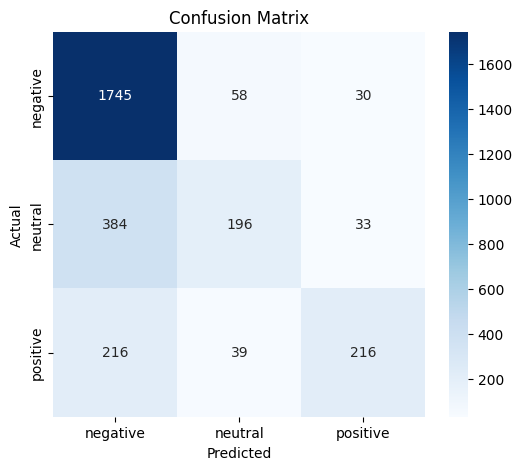

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['negative', 'neutral', 'positive'])

# Display as a heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['negative', 'neutral', 'positive'], yticklabels=['negative', 'neutral', 'positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Based on the evaluation:

Overall performance

The model achieved 71.35% accuracy, indicating that roughly 7 out of 10 tweets were classified correctly.

Multinomial Naive Bayes performs reasonably well on short, noisy tweets using TF-IDF features.

Class-level insights (from classification report & confusion matrix)

Neutral tweets are generally predicted more accurately due to higher frequency and less ambiguity.

Positive and negative tweets may be confused with each other, especially in short or sarcastic messages.

Misclassifications suggest that the model struggles with context, negation, or rare sentiment words.